In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Cleaning corrupted images...
Removing TensorFlow-corrupted image: /content/drive/MyDrive/PetImages/Cat/4351.jpg due to error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 
Removing TensorFlow-corrupted image: /content/drive/MyDrive/PetImages/Cat/10404.jpg due to error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
Removing TensorFlow-corrupted image: /content/drive/MyDrive/PetImages/Dog/9500.jpg due to error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 
Removing TensorFlow-corrupted image: /content/drive/MyDrive/PetImages/Dog/2317.jpg due to error: {{function_node __

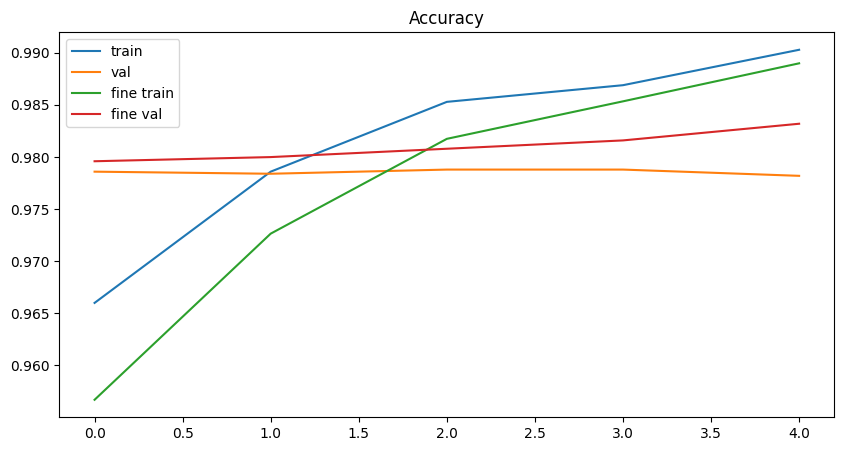

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


Prediction: 🐱 Cat
✅ Model saved successfully!


In [4]:
# ================================
# 1. INSTALL & IMPORT
# ================================
!pip install tensorflow matplotlib pillow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image


# ================================
# 3. DATASET PATH
# ================================
data_dir = "/content/drive/MyDrive/PetImages"  # CHANGE if needed

# ================================
# 4. CLEAN CORRUPTED IMAGES
# ================================
print("Cleaning corrupted images...")
num_corrupted = 0
for folder in ["Cat", "Dog"]:
    folder_path = os.path.join(data_dir, folder)
    if not os.path.exists(folder_path):
        print(f"Folder {folder_path} not found. Skipping.")
        continue
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        try:
            # Try to read and decode image using TensorFlow
            img_bytes = tf.io.read_file(file_path)
            _ = tf.image.decode_image(img_bytes, channels=3) # Try decoding, forcing 3 channels
        except tf.errors.InvalidArgumentError as e:
            print(f"Removing TensorFlow-corrupted image: {file_path} due to error: {e}")
            os.remove(file_path)
            num_corrupted += 1
        except Exception as e: # Catch other potential errors (e.g., from tf.io.read_file or other image issues)
            print(f"Removing other corrupted image: {file_path} due to error: {e}")
            os.remove(file_path)
            num_corrupted += 1

print(f"Dataset cleaned! Removed {num_corrupted} corrupted images.")

# ================================
# 5. LOAD DATASET (AUTO SPLIT)
# ================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(160, 160),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(160, 160),
    batch_size=32
)

# ================================
# 6. OPTIMIZE
# ================================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# ================================
# 7. LOAD MOBILENETV2
# ================================
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# ================================
# 8. BUILD MODEL
# ================================
model = keras.Sequential([
    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

# ================================
# 9. COMPILE
# ================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ================================
# 10. TRAIN (PHASE 1)
# ================================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

# ================================
# 11. FINE-TUNING (PHASE 2)
# ================================
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

# ================================
# 12. PLOT RESULTS
# ================================
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')

plt.plot(history_fine.history['accuracy'], label='fine train')
plt.plot(history_fine.history['val_accuracy'], label='fine val')

plt.legend()
plt.title("Accuracy")
plt.show()

# ================================
# 13. TEST PREDICTION
# ================================
from tensorflow.keras.preprocessing import image

test_img_path = os.path.join(data_dir, "Cat", os.listdir(os.path.join(data_dir, "Cat"))[0])

img = image.load_img(test_img_path, target_size=(160,160))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Prediction: 🐶 Dog")
else:
    print("Prediction: 🐱 Cat")

# ================================
# 14. SAVE MODEL
# ================================
model.save("/content/drive/MyDrive/pet_classifier_mobilenet.h5")

print("✅ Model saved successfully!")

### Predict with an image from a specified path

First, define the path to your input image file in Google Drive. Make sure the path is correct.

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Define the path to your input image file
# IMPORTANT: Change this path to your actual image file in Google Drive
input_image_path = '/content/drive/MyDrive/input image /Copy of 55.jpg' # Example path

# Load the previously saved model
# Ensure the path to your saved model is correct
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/pet_classifier_mobilenet.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


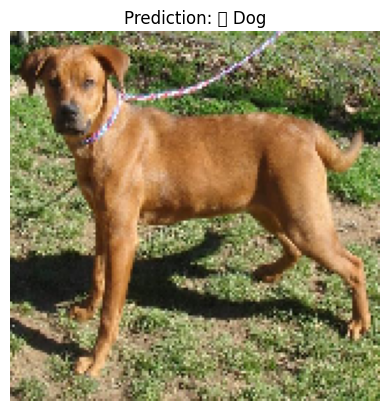

Prediction: 🐶 Dog


In [6]:
# Load and preprocess the input image
img = image.load_img(input_image_path, target_size=(160, 160))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

# Make prediction using the loaded model
prediction_result = loaded_model.predict(img_array)

# Display the image and prediction
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {'🐶 Dog' if prediction_result[0] > 0.5 else '🐱 Cat'}")
plt.show()

if prediction_result[0] > 0.5:
    print("Prediction: 🐶 Dog")
else:
    print("Prediction: 🐱 Cat")

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Define the path to your input image file
# IMPORTANT: Change this path to your actual image file in Google Drive
input_image_path = '/content/drive/MyDrive/input image /Copy of 50.jpg' # Example path

# Load the previously saved model
# Ensure the path to your saved model is correct
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/pet_classifier_mobilenet.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


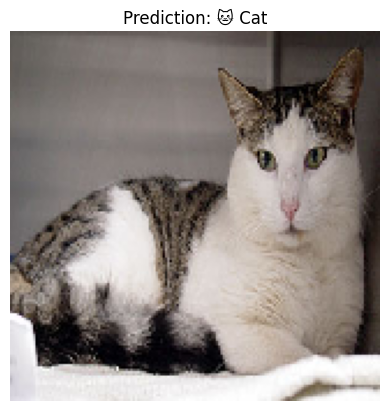

Prediction: 🐱 Cat


In [8]:
# Load and preprocess the input image
img = image.load_img(input_image_path, target_size=(160, 160))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

# Make prediction using the loaded model
prediction_result = loaded_model.predict(img_array)

# Display the image and prediction
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {'🐶 Dog' if prediction_result[0] > 0.5 else '🐱 Cat'}")
plt.show()

if prediction_result[0] > 0.5:
    print("Prediction: 🐶 Dog")
else:
    print("Prediction: 🐱 Cat")